In [259]:
import scipy
import math
from scipy.stats import median_abs_deviation as mad
import numpy as np
from matplotlib import pyplot as plt
import time
from  scipy.io import loadmat as loadmat
import os

In [260]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Uni/ImageProcessing')
rootfolder = 'Colab Students - Assignments/data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Useful function for the plot

In [261]:
def display_band( X, par,epsi=0.001,col='k'):
    x1 = np.min(X[0, :])
    x2 = np.max(X[0, :])
    y1 = np.min(X[1, :])
    y2 = np.max(X[1, :])

    # extend the line for the k# of its lenght
    k = 0.01
    dx = x2-x1
    dy = y2-y1
    l = np.sqrt(dx**2+dy**2)
    x1 = x1 - k*l
    x2 = x2 + k*l
    y1 = y1 - k*l
    y2 = y2 + k*l
    ##
    if np.abs(par[1])<2e-2 :
        #disp('vertical line')
        a = np.vstack([-(par[1]*y1 + par[2])/par[0], y1])
        b = np.vstack([-(par[1]*y2 + par[2])/par[0], y2])
    else:
        a = np.vstack([x1, -(par[0]*x1 + par[2])/par[1]])
        b = np.vstack([x2, -(par[0]*x2 + par[2])/par[1]])

    if np.abs(par[0])<1e-5:
        v = np.array([0,1])
    else:
        v = np.array([1, par[1]/par[0]])# direction perpendicular to the line;

    v = v / np.sqrt(np.sum(v**2))
    # corners of the bands
    v = v[:, np.newaxis]
    a1 = a - epsi * v
    a2 = a + epsi * v
    b1 = b - epsi * v
    b2 = b + epsi * v

    px = np.array([a1[0], b1[0], b2[0], a2[0]]).squeeze()
    py = np.array([a1[1], b1[1], b2[1], a2[1]]).squeeze()
    plt.tricontourf(px,py,np.ones_like(px), colors=col,alpha=0.5)
    plt.gca().set_aspect('equal')

def display_clust(X, G, cmap):
    G = np.asarray(G, dtype=int)
    switch_out = 1
    smb = 'o'
    col = []
    num_clust = int(np.max(G))

    for i in range(1, num_clust+1):
        id = G == i
        id = id.squeeze()
        x = X[0, id]
        y = X[1, id]
        if len(col) == 0:
            plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
        else:
            plt.scatter(x,y,50,col,marker=smb,edgecolors=col, alpha=0.1)
        if switch_out == 1:
            id = G == 0
            id = id.squeeze()
            plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)

Function that computes the residual between points and a line

In [262]:
def res_line(X, M):
  if len(M.shape) > 1:
    num_lines = M.shape[1]
  else:
    num_lines = 1

  if num_lines == 1:
    d = np.abs(M[0] * X[0, :] + M[1] * X[1, :] + M[2])
  else:
    n = X.shape[1]
    d = np.zeros((n, num_lines))
    for i in range(num_lines):
      d[:, i] = np.abs(M[0, i] * X[0, :] + M[1, i] * X[1, :] + M[2, i])
  return d


Functions to add outlier to the dataset

In [263]:
def addOutliersInBB(X, nOutliers, k=0.1):
    xmin = np.min(X[0, :])
    xmax = np.max(X[0, :])
    ymin = np.min(X[1, :])
    ymax = np.max(X[1, :])
    wx = xmax-xmin
    wy = ymax -ymin
    dx = k*wx
    dy = k*wy

    Y = np.hstack((X,np.vstack((xmax-xmin+2*dx * np.random.uniform(size=(1, nOutliers)) + xmin-dx,
                             ymax-ymin+2*dy * np.random.uniform(size=(1, nOutliers)) + ymin-dy))
                ))
    return Y



Ransac
------
Use the implementation from the last lecture

In [264]:
def fit_line_dlt(P):
    # centering data
    mu = np.mean(P, axis=1, keepdims=True)
    Pc = P - mu

    # SVD
    U, S, Vt = np.linalg.svd(Pc.T, full_matrices=False)
    n = Vt[-1, :]

    #line param
    c = -np.dot(n, mu).item()
    theta = np.array([n[0], n[1], c])

    # mtrics
    residuals = np.abs(theta[0]*P[0,:] + theta[1]*P[1,:] + theta[2]) / np.sqrt(theta[0]**2 + theta[1]**2)
    residual_error = np.sum(residuals**2)

    return theta, residuals, residual_error

In [265]:
def simpleRANSAC(X, eps, cardmss=2):
    #init
    max_iter = 1000
    best_inliers_count = 0
    bestmodel = None
    bestinliers = None
    num_pts = X.shape[1]

    for _ in range(max_iter):
        idx = np.random.choice(num_pts, cardmss, replace=False)
        sample = X[:, idx]

        # model fitting
        theta, _, _ = fit_line_dlt(sample)

        # inlier eval
        distances = np.abs(theta[0]*X[0,:] + theta[1]*X[1,:] + theta[2]) / np.sqrt(theta[0]**2 + theta[1]**2)
        inliers = distances < eps
        inliers_count = np.sum(inliers)

        # update best model
        if inliers_count > best_inliers_count:
            best_inliers_count = inliers_count
            bestinliers = inliers
            bestmodel = theta

    return bestmodel, bestinliers

Sequential Ransac
-----------------
Prepare the dataset and set the parameters


In [266]:
epsi = 0.02 # inlier threshold for ransac

temp = loadmat(f'{rootfolder}/star5.mat')
#temp = loadmat(f'{rootfolder}/stair4.mat')

X = temp['X'] # data
G = temp['G'] # ground truth or label (1: normal, 0: outlier)

# model specification
# functions to fit and compute residuals are already invoked in the function
cardmss = 2          # minimum number of points required to fit a model
kappa = 10           # number of models to be extracted by sequential ransac

#  plotting params
bw = 0.01
col = 'b'
temp = loadmat(f'{rootfolder}/cmap.mat')
cmap = temp['cmap']

# add outliers
nOut = 10

# add outlier and update groundtruth
X = addOutliersInBB(X,nOut)

# update the label, considering that X previous command has appended nOut otliers
print(G.shape)
G = np.vstack((G, np.zeros((nOut, 1))))

(250, 1)


/tmp/ipykernel_5200/2810163066.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
/tmp/ipykernel_5200/2810163066.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


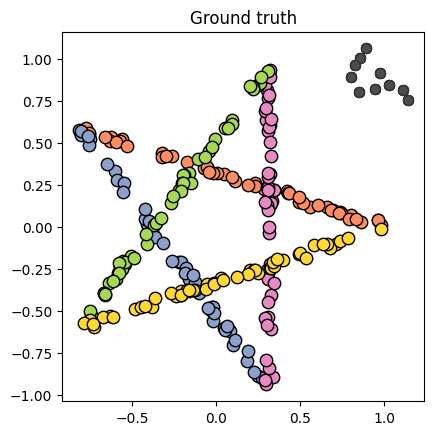

In [267]:
plt.figure(1)
display_clust(X,G, cmap)
plt.title('Ground truth')
plt.gca().set_aspect('equal')
plt.show()

Implement the sequential ransac algorithm

In [268]:
Y = X.copy() # take a copy of X to be modified

# define cells to contain the fitted models
currentModel = []
currentInliers = []

E_min = 10 # minimum number of expected inliers for each
drop_ratio = 0.4

cnt = 0
while cnt < kappa:
    # find model with ransac (save currentModel and currentInliers for visualization)
    model, inliers = simpleRANSAC(Y, epsi, cardmss)
    current_consensus = np.sum(inliers)

    if current_consensus < E_min:
        break

    #   consensus drop logic
    if cnt > 0 and current_consensus < drop_ratio * np.sum(currentInliers[-1]):
        break

    currentModel.append(model)
    currentInliers.append(inliers)



    # remove current inliers
    Y = Y[:, ~inliers]

    # update iterations
    cnt += 1

# TODO: implement another stopping criteria based on the consensus of the last model found
# OK


Show the iteration of Sequential Ransac

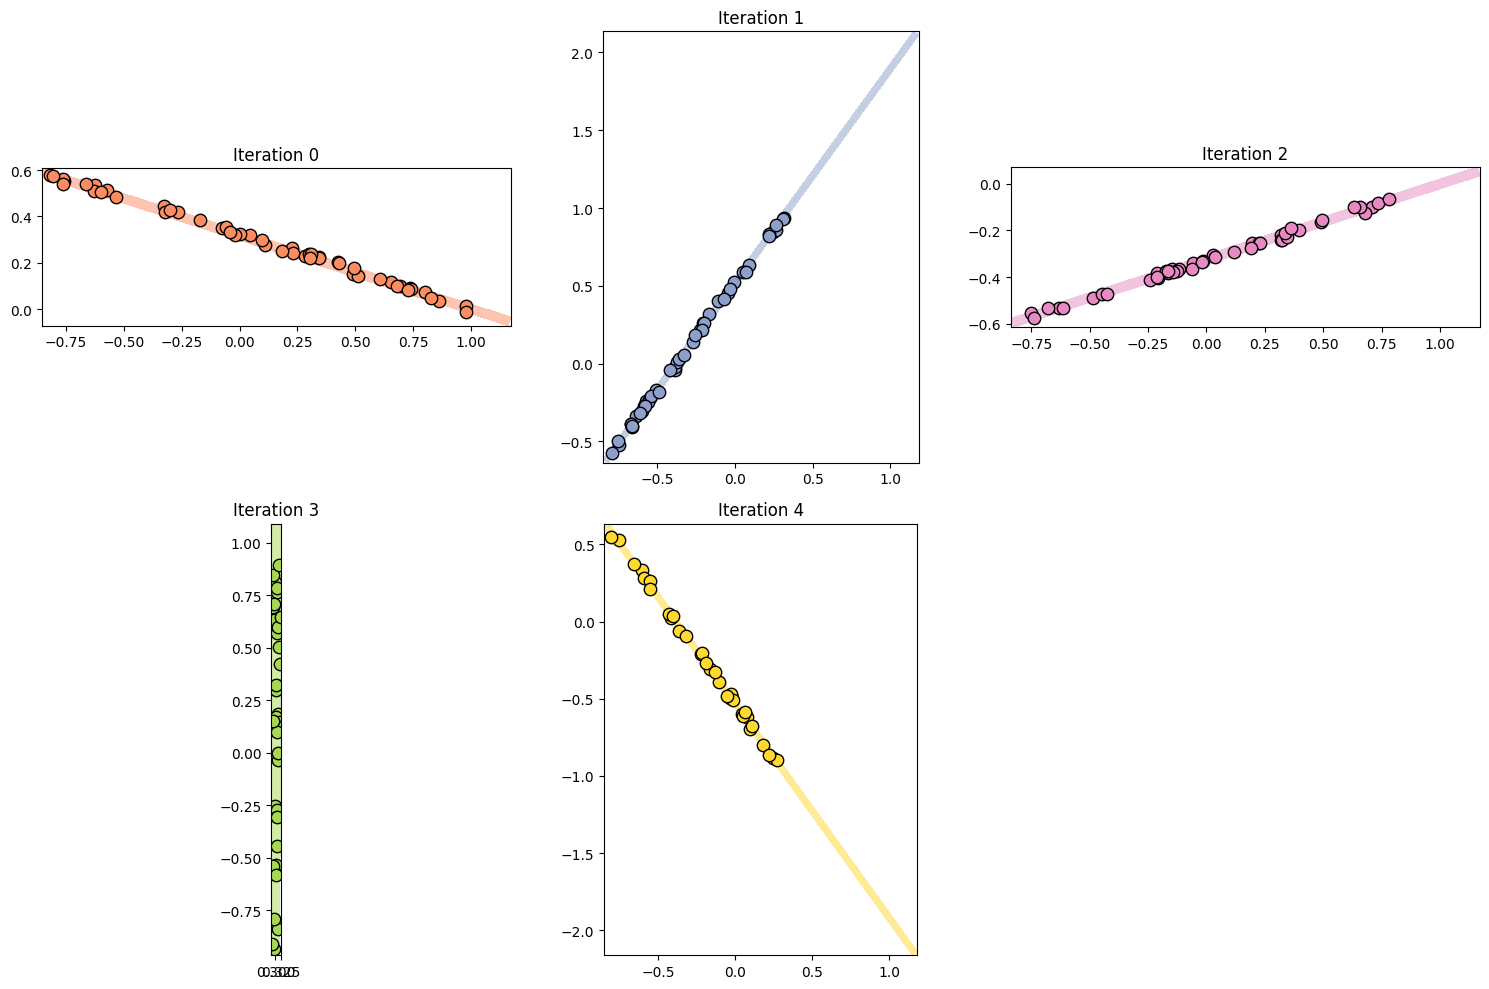

In [269]:
n_models = len(currentModel)
cols = min(3, n_models)
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))

# Handle flat array of axes
if n_models > 1:
    axes = axes.flatten()
else:
    axes = [axes]

Y = X.copy()

# to adjust the iteration and index out of range error
if kappa > len(currentModel):
    kappa = len(currentModel)

for i in range(kappa):
    plt.sca(axes[i])
    axes[i].set_aspect('equal')

    # display a band for each model estimated (see display_band function)
    display_band(Y, currentModel[i], epsi, col=cmap[i+1])

    # plot inliers for this model
    x_in = Y[0, currentInliers[i]]
    y_in = Y[1, currentInliers[i]]
    plt.scatter(x_in, y_in, 80, color=cmap[i+1], marker='o', edgecolors='k')

    # you need to remove the inliers you have plot from Y, otherwise the indexes are wrong
    Y = Y[:, ~currentInliers[i]]

    axes[i].set_title(f'Iteration {i}')

for j in range(n_models, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

TODO: Try different amount of outliers on both star and stair datasets

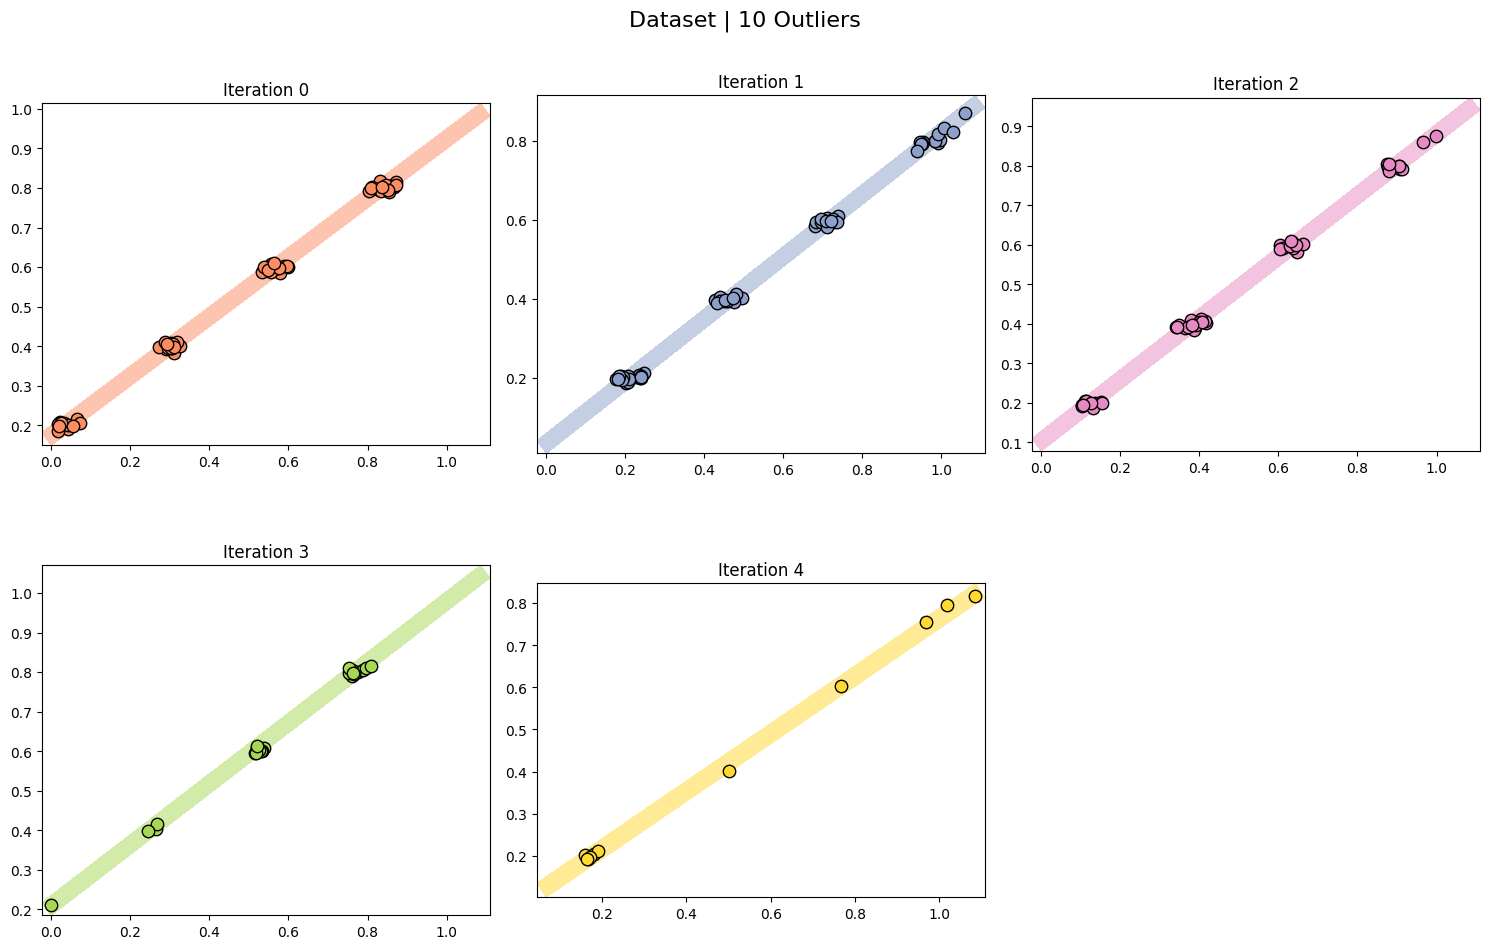

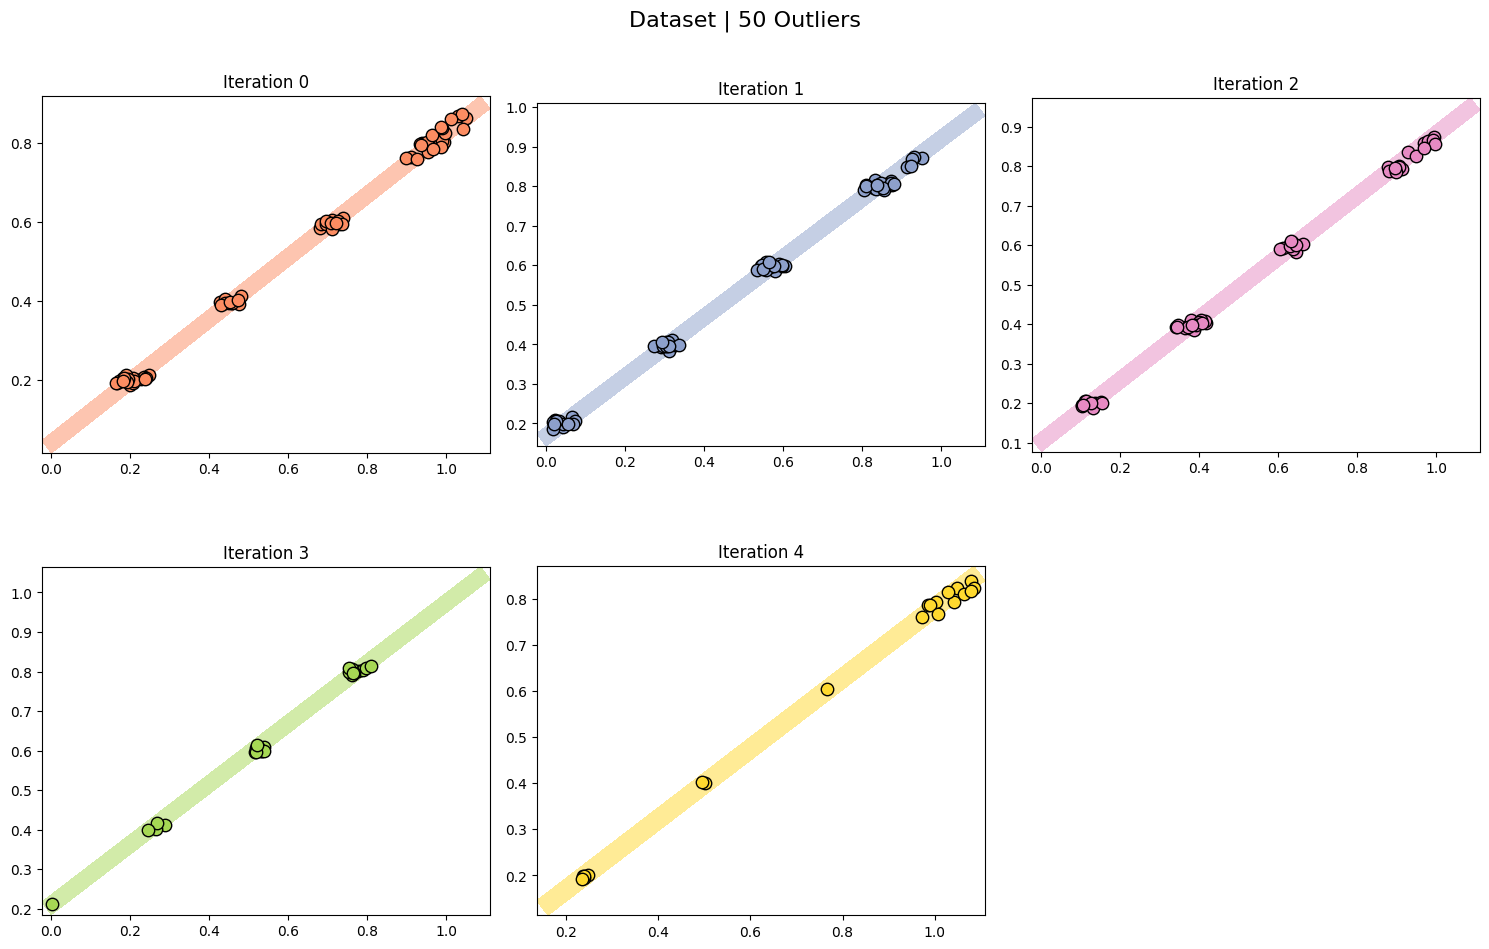

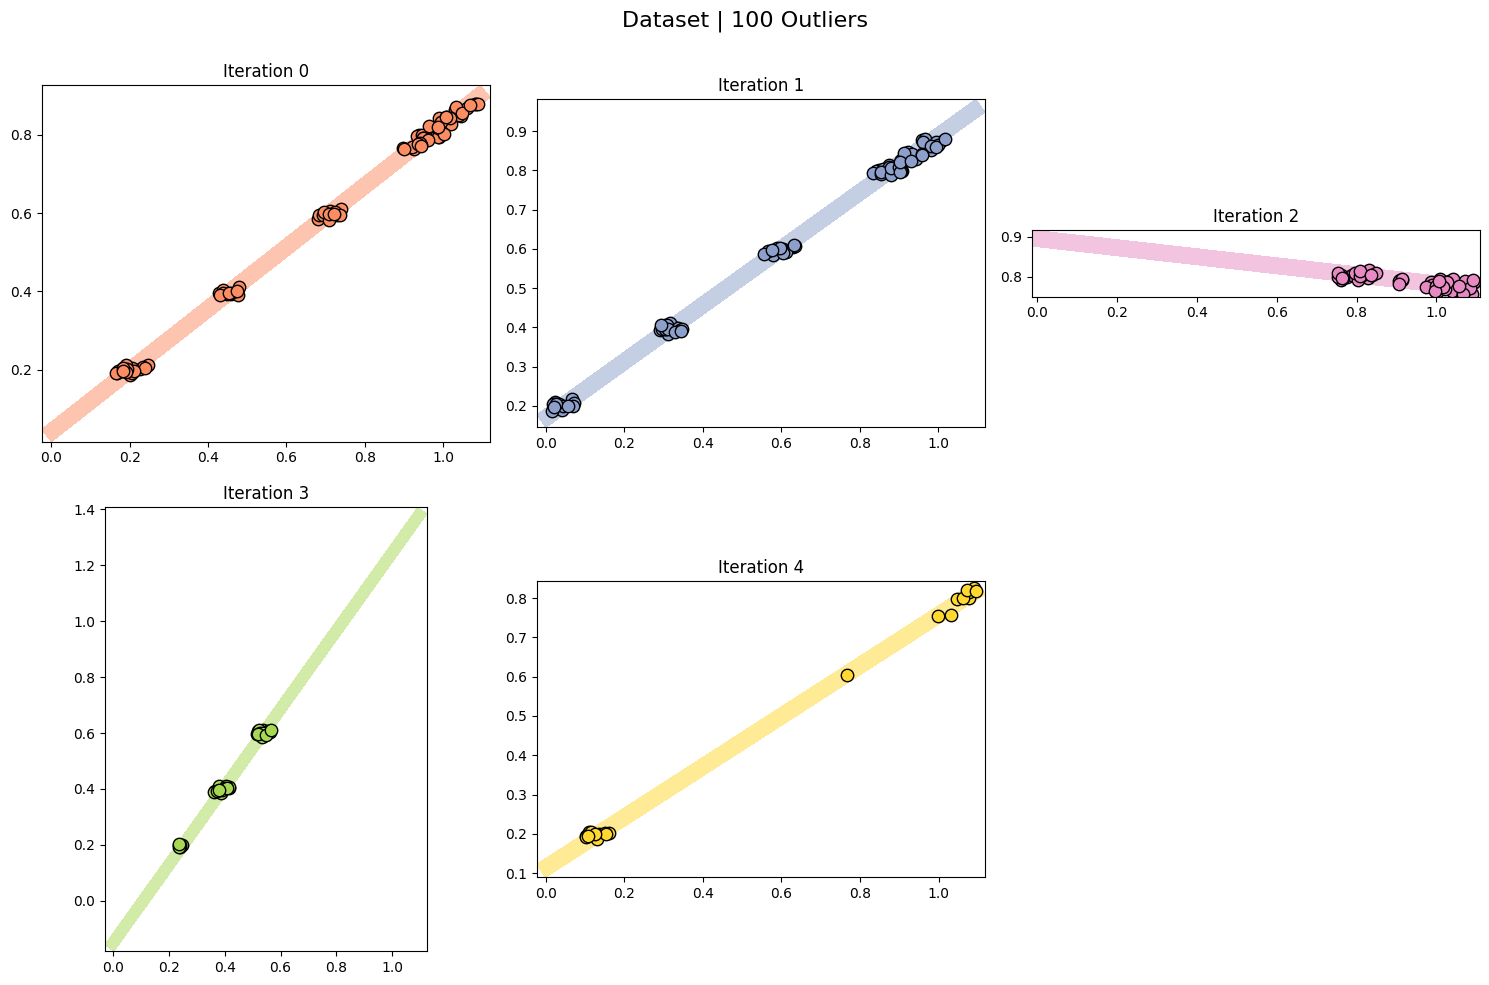

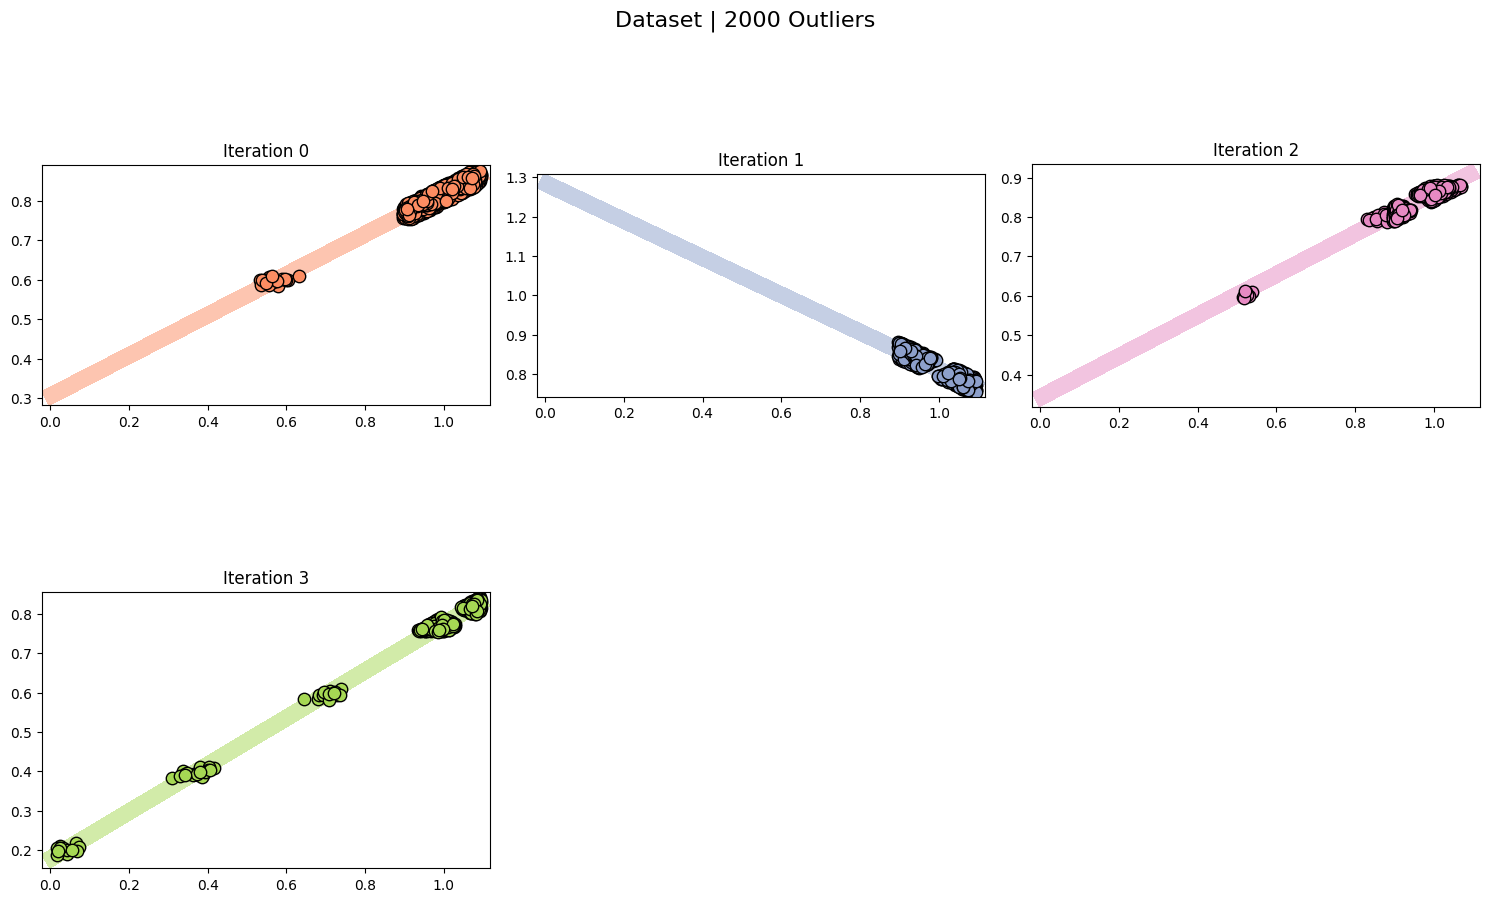

In [270]:
outlier_amounts = [10, 50, 100, 2000]

for nOut in outlier_amounts:
    # clean data
    temp = loadmat(f'{rootfolder}/stair4.mat')
    X = temp['X']

    # add outliers
    X = addOutliersInBB(X, nOut)
    Y = X.copy()

    currentModel = []
    currentInliers = []
    cnt = 0

    # sequential ransac
    while cnt < kappa:
        model, inliers = simpleRANSAC(Y, epsi, cardmss)
        current_consensus = np.sum(inliers)

        if current_consensus < E_min:
            break

        if cnt > 0 and current_consensus < drop_ratio * np.sum(currentInliers[-1]):
            break

        currentModel.append(model)
        currentInliers.append(inliers)


        Y = Y[:, ~inliers]
        cnt += 1

    # plot results
    n_models = len(currentModel)
    if n_models == 0:
        print(f"No models with {nOut} outliers.")
        continue

    cols = min(3, n_models)
    rows = math.ceil(n_models / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    fig.suptitle(f'Dataset | {nOut} Outliers', fontsize=16)

    if n_models > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    Y = X.copy()
    for i in range(n_models):
        plt.sca(axes[i])
        axes[i].set_aspect('equal')

        display_band(Y, currentModel[i], epsi, col=cmap[i+1])
        x_in = Y[0, currentInliers[i]]
        y_in = Y[1, currentInliers[i]]
        axes[i].scatter(x_in, y_in, 80, color=cmap[i+1], marker='o', edgecolors='k')

        Y = Y[:, ~currentInliers[i]]
        axes[i].set_title(f'Iteration {i}')

    for j in range(n_models, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

TODO: MultiModel fitting on circle
----------------------------
Implement Ransac (thus run Sequential Ransac) to fit circles

In [271]:
def generate_circles(n_circles=6, pts_per_circle=100, noise=0.02, outliers=500):
    X = []
    for i in range(n_circles):
        xc, yc = np.random.uniform(-5, 5, 2)
        r = np.random.uniform(1, 3)
        theta = np.linspace(0, 2*np.pi, pts_per_circle)
        x = xc + r * np.cos(theta) + np.random.normal(0, noise, pts_per_circle)
        y = yc + r * np.sin(theta) + np.random.normal(0, noise, pts_per_circle)
        X.append(np.vstack((x, y)))

    # Outliers
    x_out = np.random.uniform(-8, 8, outliers)
    y_out = np.random.uniform(-8, 8, outliers)
    X.append(np.vstack((x_out, y_out)))

    return np.hstack(X)


In [272]:
def fit_circle_dlt(P):
    x = P[0, :]
    y = P[1, :]

    # A*c = B
    A = np.column_stack((x, y, np.ones(len(x))))
    B = -(x**2 + y**2)

    # ls sq
    c, _, _, _ = np.linalg.lstsq(A, B, rcond=None)

    xc = -c[0] / 2
    yc = -c[1] / 2

    r_sq = xc**2 + yc**2 - c[2]
    if r_sq < 0:
        return np.array([np.nan, np.nan, np.nan]), None, np.inf

    r = np.sqrt(r_sq)
    theta = np.array([xc, yc, r])

    # residuals
    distances = np.abs(np.sqrt((x - xc)**2 + (y - yc)**2) - r)
    residual_error = np.sum(distances**2)

    return theta, distances, residual_error

In [273]:
def simpleRANSAC_circle(X, eps, cardmss=3):
    max_iter = 1000
    best_inliers_count = 0
    bestmodel = None
    bestinliers = None
    num_pts = X.shape[1]

    for _ in range(max_iter):
        idx = np.random.choice(num_pts, cardmss, replace=False)
        sample = X[:, idx]

        # fit
        theta, _, _ = fit_circle_dlt(sample)

        if np.isnan(theta[2]):
            continue

        # eval inliers
        distances = np.abs(np.sqrt((X[0,:] - theta[0])**2 + (X[1,:] - theta[1])**2) - theta[2])
        inliers = distances < eps
        inliers_count = np.sum(inliers)

        if inliers_count > best_inliers_count:
            best_inliers_count = inliers_count
            bestinliers = inliers
            bestmodel = theta

    return bestmodel, bestinliers

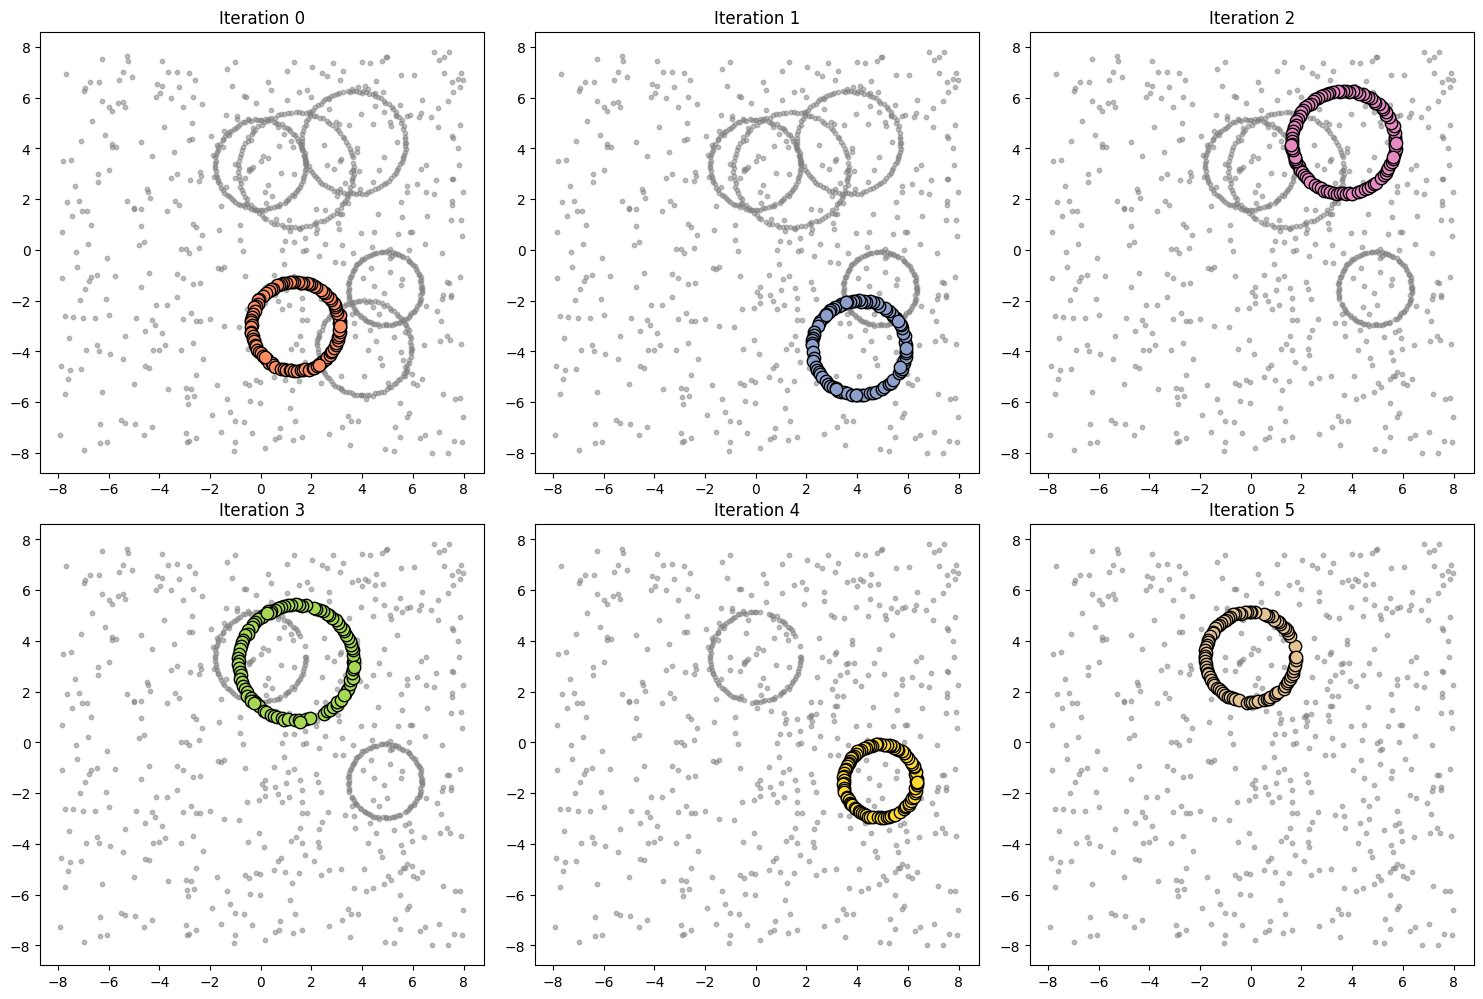

In [276]:
cardmss = 3 # 3 points for define a circol
epsi = 0.05

X_circles = generate_circles()
Y = X_circles.copy()

currentModel = []
currentInliers = []

E_min = 10
drop_ratio = 0.5
kappa = 10
cnt = 0

while cnt < kappa:
    model, inliers = simpleRANSAC_circle(Y, epsi, cardmss)
    current_consensus = np.sum(inliers)

    if current_consensus < E_min:
        break

    # consensus drop logic
    if cnt > 0 and current_consensus < drop_ratio * np.sum(currentInliers[-1]):
        break

    currentModel.append(model)
    currentInliers.append(inliers)

    # remove current inliers
    Y = Y[:, ~inliers]
    cnt += 1


n_models = len(currentModel)
cols = min(3, n_models) if n_models > 0 else 1
rows = math.ceil(n_models / cols) if n_models > 0 else 1

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))

if n_models > 1:
    axes = axes.flatten()
else:
    axes = [axes]

Y = X_circles.copy()

for i in range(n_models):
    plt.sca(axes[i])
    axes[i].set_aspect('equal')

    # background points
    axes[i].scatter(Y[0,:], Y[1,:], s=10, c='gray', alpha=0.5)

    # draw circle model
    xc, yc, r = currentModel[i]
    circle = plt.Circle((xc, yc), r, color=cmap[i+1], fill=False, linewidth=3)
    axes[i].add_patch(circle)

    # plot inliers
    x_in = Y[0, currentInliers[i]]
    y_in = Y[1, currentInliers[i]]
    axes[i].scatter(x_in, y_in, 80, color=cmap[i+1], marker='o', edgecolors='k')

    # remove  inliers
    Y = Y[:, ~currentInliers[i]]

    axes[i].set_title(f'Iteration {i}')

for j in range(n_models, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()